Create toy example for testing of the Split Augmented Langevin algorithm from [Blanke & al. 2025]

### 1. Define the dataset

In [46]:
import numpy as np

class GaussianMixture:
    def __init__(self, parameters):
        self.parameters = parameters
        self.distributions = [
            {
                'mean': np.array(dist['mean']),
                'std': np.array(dist['std']),
                'cov': np.diag(np.array(dist['std']) ** 2)
            }
            for dist in parameters
        ]

    def sample(self, num_samples):
        samples = []
        num_distributions = len(self.distributions)
        for _ in range(num_samples):
            idx = np.random.randint(num_distributions)  # Choose a random Gaussian
            dist = self.distributions[idx]
            sample = np.random.multivariate_normal(mean=dist['mean'], cov=dist['cov'])
            samples.append(sample)
        return np.array(samples)

parameters = [
    {"mean": [0, 0], "std": [1, 1]},
    {"mean": [3, 2], "std": [0.5, 0.5]}
]
mixture = GaussianMixture(parameters)

### 2. Define the Diffusion model 
code adapted from https://www.physicsbaseddeeplearning.org/probmodels-intro.html

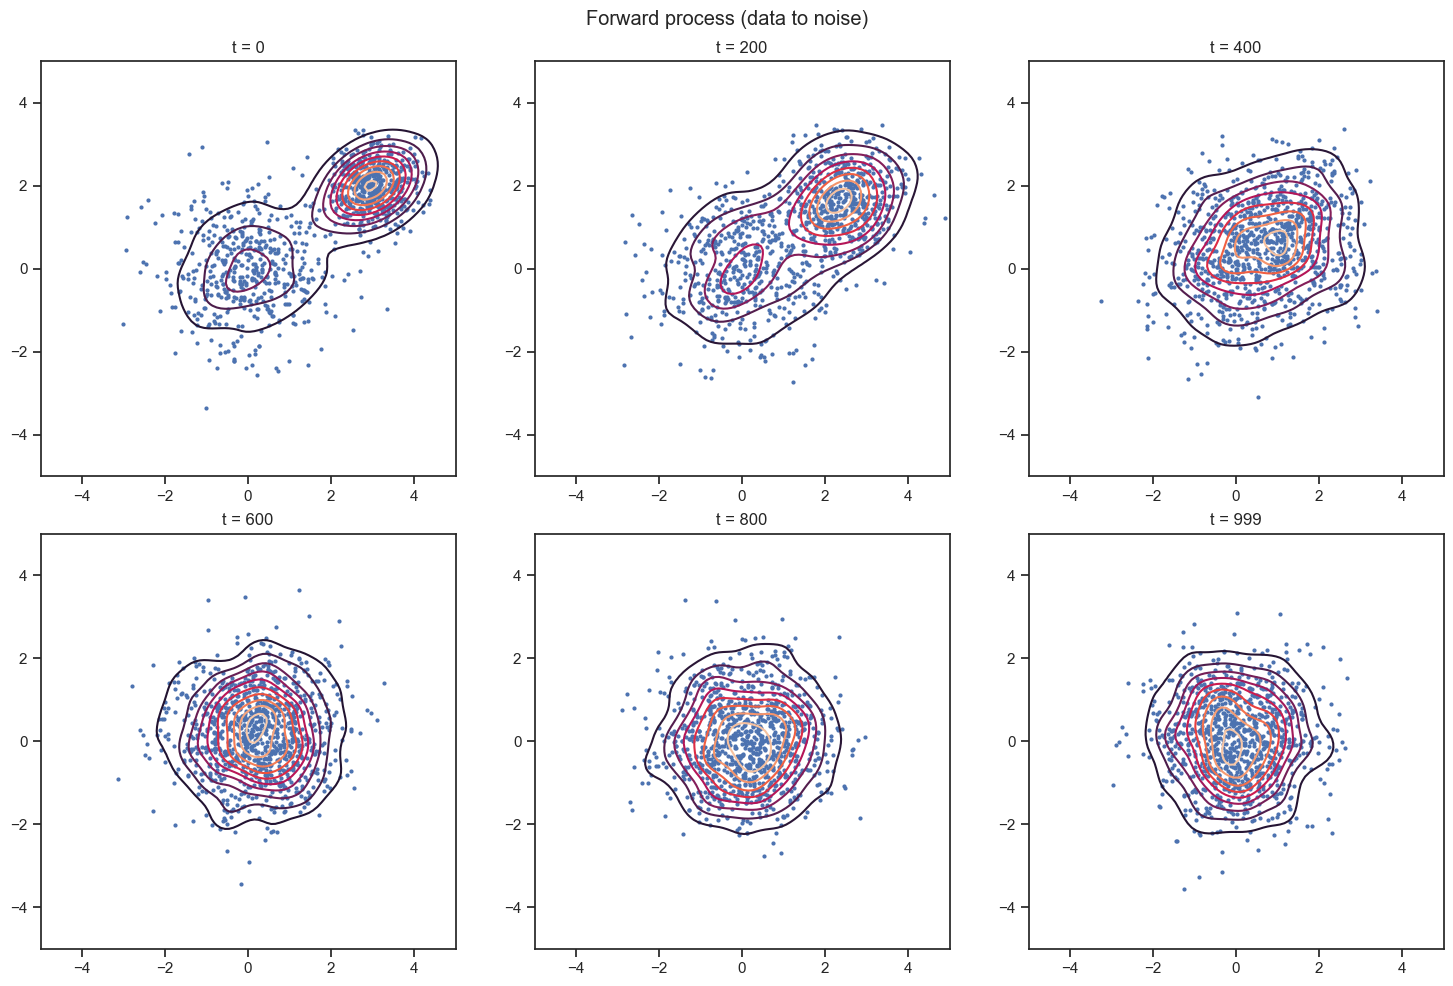

In [47]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

class DDPMForwardProcess:
    def __init__(self, num_timesteps=1000):
        self.num_timesteps = num_timesteps

        # Standard beta schedule from DDPM paper
        scale = 1000 / num_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)

        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_betas = torch.sqrt(self.betas)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)

    def forward_process(self, x_0, t):
        epsilon = torch.randn_like(x_0)
        mean = self.sqrt_alphas_cumprod[t] * x_0
        std = self.sqrt_one_minus_alphas_cumprod[t]
        return mean + std * epsilon, epsilon

    def visualize_forward_process(self, mixture, num_samples=1000):

        timesteps_to_show=[0, 200, 400, 600, 800, 999]
        x_0 = torch.FloatTensor(mixture.sample(num_samples))

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        xx, yy = np.mgrid[-5:5:100j, -5:5:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])

        for idx, t in enumerate(timesteps_to_show):
            x_t, _ = self.forward_process(x_0, t)
            samples = x_t.numpy()

            from scipy.stats import gaussian_kde
            kernel = gaussian_kde(samples.T)
            density = np.reshape(kernel(positions).T, xx.shape)

            ax = axes[idx]

            ax.contour(xx, yy, density, levels=10, alpha=1.0)

            ax.scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=4)

            ax.set_xlim(-5, 5)
            ax.set_ylim(-5, 5)
            ax.set_aspect('equal')
            ax.set_title(f't = {t}')

        plt.suptitle("Forward process (data to noise)")

        plt.tight_layout()
        plt.show()

ddpm = DDPMForwardProcess(num_timesteps=1000)
ddpm.visualize_forward_process(mixture)

In [48]:
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ForwardDiffusionDataset(Dataset):
    def __init__(self, num_samples, input_dim,
                 T, mixture, beta_value=0.02):
        super().__init__()
        self.num_samples = num_samples
        self.input_dim = input_dim
        self.T = T
        self.beta_value = beta_value
        self.gm = mixture

        self.betas = beta_value * torch.ones(T)
        self.alphas = 1 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

        self.x0 = torch.FloatTensor(self.gm.sample(num_samples))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x0_sample = self.x0[idx]
        t = torch.randint(low=1, high=self.T + 1, size=(1,)).item()
        eps = torch.randn(self.input_dim)
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t - 1])
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar[t - 1])

        x_t = sqrt_alpha_bar * x0_sample + sqrt_one_minus_alpha_bar * eps

        return x_t, torch.tensor(t, dtype=torch.float32), eps

In [49]:
class DdpmNet(nn.Module):
    def __init__(self, in_dim=2, time_dim=1, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

### 3. Model training

In [50]:
num_samples = 10000
input_dim = 2
T = 1000
dataset = ForwardDiffusionDataset(num_samples=num_samples, input_dim=input_dim, T=T, mixture=mixture, beta_value=0.02)
batch_size = 64
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# %% Training the DDPM model
time_dim = 1
hidden_dim = 128
model = DdpmNet(in_dim=input_dim, time_dim=time_dim, hidden_dim=hidden_dim, out_dim=input_dim)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 100
model.train()
for epoch in range(1, epochs + 1):
    epoch_loss = 0
    for x_t_batch, t_batch, eps_batch in data_loader:
        optimizer.zero_grad()
        # Normalize time t to range [0,1]
        t_norm = t_batch / T
        eps_pred = model(x_t_batch, t_norm)
        loss = loss_fn(eps_pred, eps_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(data_loader)
    print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/100, Loss: 0.1484
Epoch 2/100, Loss: 0.0823
Epoch 3/100, Loss: 0.0825
Epoch 4/100, Loss: 0.0757
Epoch 5/100, Loss: 0.0733
Epoch 6/100, Loss: 0.0730
Epoch 7/100, Loss: 0.0691
Epoch 8/100, Loss: 0.0665
Epoch 9/100, Loss: 0.0719
Epoch 10/100, Loss: 0.0714
Epoch 11/100, Loss: 0.0711
Epoch 12/100, Loss: 0.0749
Epoch 13/100, Loss: 0.0706
Epoch 14/100, Loss: 0.0674
Epoch 15/100, Loss: 0.0659
Epoch 16/100, Loss: 0.0668
Epoch 17/100, Loss: 0.0695
Epoch 18/100, Loss: 0.0650
Epoch 19/100, Loss: 0.0679
Epoch 20/100, Loss: 0.0634
Epoch 21/100, Loss: 0.0705
Epoch 22/100, Loss: 0.0616
Epoch 23/100, Loss: 0.0676
Epoch 24/100, Loss: 0.0644
Epoch 25/100, Loss: 0.0675
Epoch 26/100, Loss: 0.0622
Epoch 27/100, Loss: 0.0657
Epoch 28/100, Loss: 0.0677
Epoch 29/100, Loss: 0.0673
Epoch 30/100, Loss: 0.0653
Epoch 31/100, Loss: 0.0664
Epoch 32/100, Loss: 0.0654
Epoch 33/100, Loss: 0.0627
Epoch 34/100, Loss: 0.0614
Epoch 35/100, Loss: 0.0614
Epoch 36/100, Loss: 0.0610
Epoch 37/100, Loss: 0.0608
Epoch 38/1

In [51]:
n_infer = 1000

betas = 0.02 * torch.ones(T)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

with torch.no_grad():
    x = torch.randn(n_infer, input_dim)

    record_steps = {999, 500, 200, 100, 50, 1}
    snapshots = {}

    for t in range(T, 0, -1):

        t_tensor = (torch.ones(n_infer) * t / T).float()
        eps_theta = model(x, t_tensor)

        beta_t = betas[t - 1]
        alpha_t = alphas[t - 1]
        alpha_bar_t = alpha_bar[t - 1]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        x = (1 / torch.sqrt(alpha_t)) * (x - coef * eps_theta)

        if t > 1:
            sigma_t = torch.sqrt(beta_t)
            x = x + sigma_t * torch.randn_like(x)

        if t in record_steps:
            snapshots[t] = x.clone().cpu().numpy()

In [52]:
import matplotlib.pyplot as plt

def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:    # 0 degrees to 120 degrees (R->G)
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:  # 120 degrees to 240 degrees (G->B)
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:               # 240 degrees to 360° (B->R)
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]

    return colors

def visualize_snapshots(snapshots):

    sorted_steps = sorted(snapshots.keys(), reverse=True)
    n_plots = len(sorted_steps)

    fig, axes = plt.subplots(2, 3, figsize=(5 * 3, 8))
    axes = axes.ravel()

    if n_plots == 1:
        axes = [axes]

    # Create grid for density visualization
    xx, yy = np.mgrid[-5:5:100j, -5:5:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    idx = 0
    for ax, t in zip(axes, sorted_steps):

        samples = snapshots[t]

        if idx == 0:
            c = get_angle_colors(samples)
            idx += 1

        x_0 = torch.FloatTensor(mixture.sample(num_samples))
        x_t, _ = ddpm.forward_process(x_0, t)
        samples_ = x_t.numpy()

        from scipy.stats import gaussian_kde
        kernel = gaussian_kde(samples_.T)
        density = np.reshape(kernel(positions).T, xx.shape)

        ax.contour(xx, yy, density, levels=10, alpha=0.8)

        ax.scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=5, color=c)
        #ax.plot([-2,-1,0,1,2], [2,1,0,-1,-2],c='g')
        #ax.plot([2,1,0,-1,-2], [2,1,0,-1,-2],c='g')
        ax.set_title(f"t = {t}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True)

    plt.suptitle("Diffusion Model Reverse Process")
    plt.tight_layout()
    plt.show()

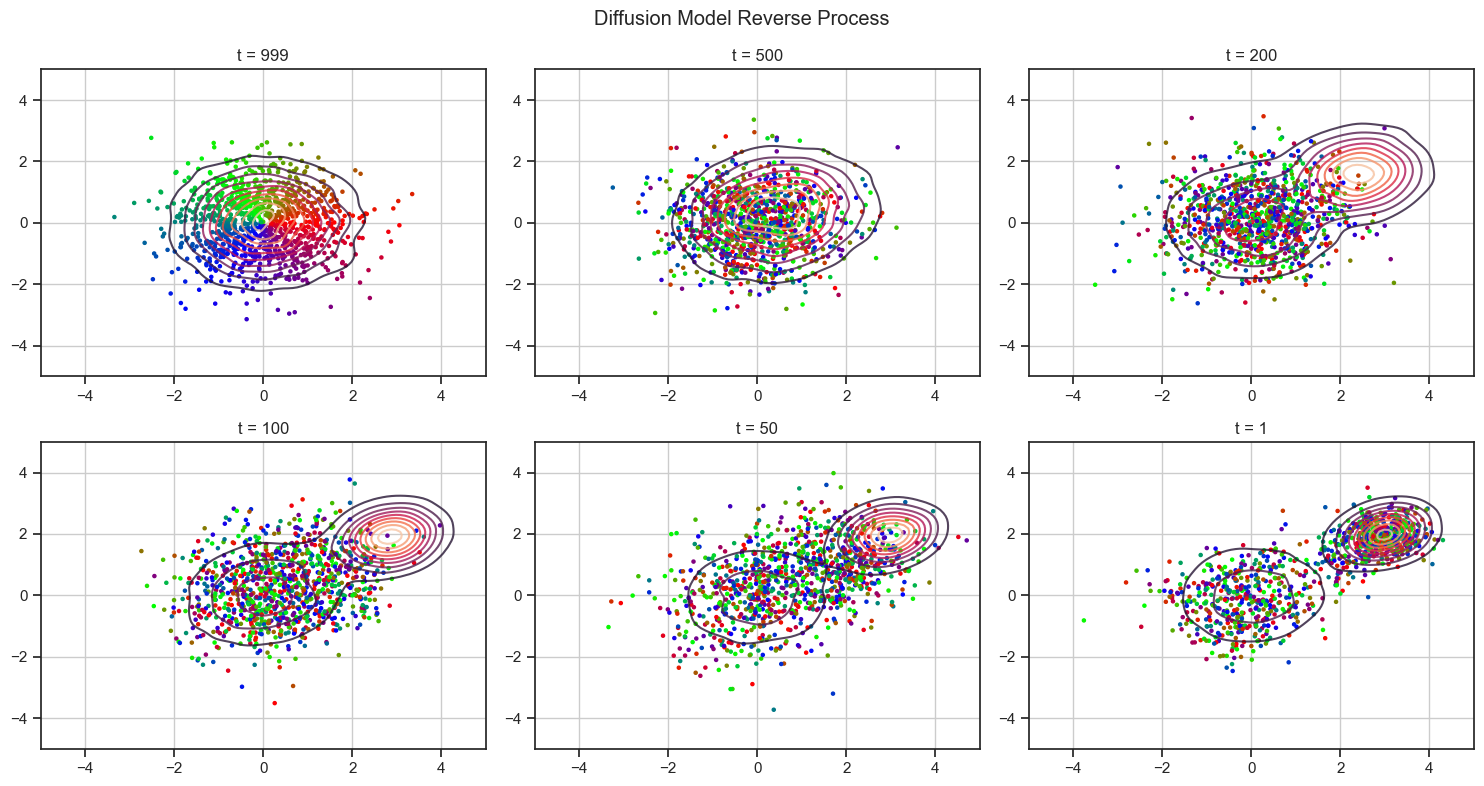

In [53]:
visualize_snapshots(snapshots)

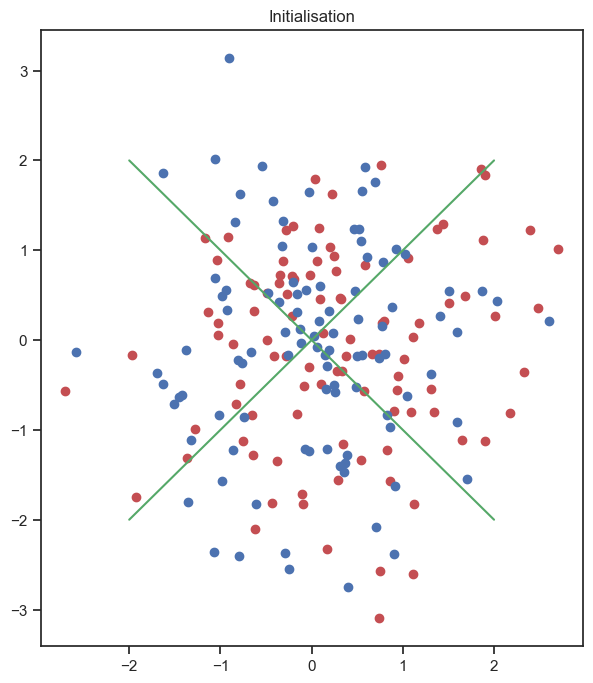

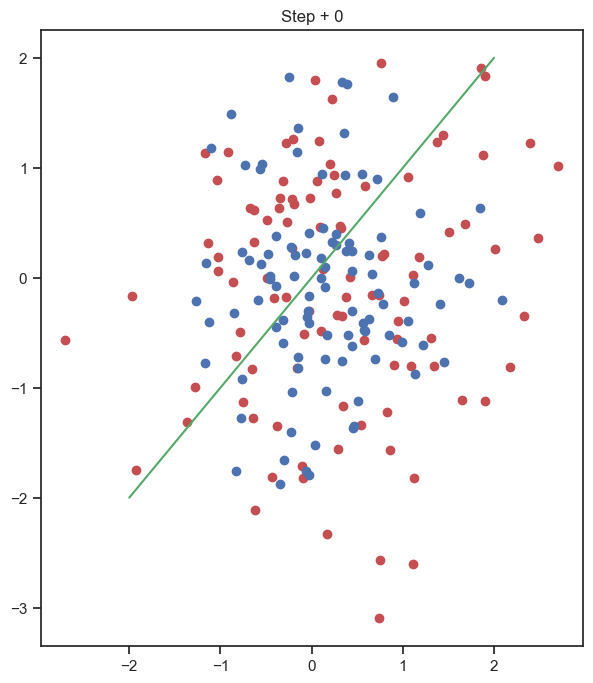

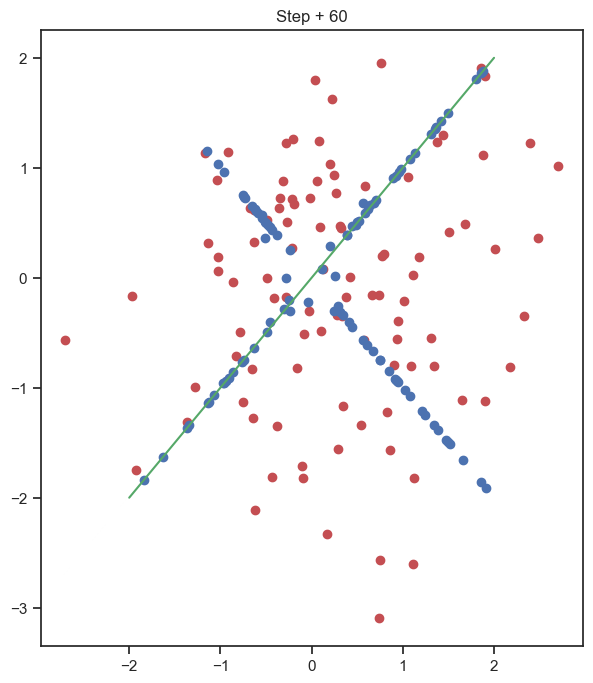

In [94]:
#constraint simplified C = {x, x_1 + x_2 = 0}
def constraint_line(x,y):
    return x - y

def constraint_cross(x,y):
    return x**2 - y**2

def optim_primal_dual(z, x, eps, constraint=constraint_cross, eta=0.001, plot=True):
    l = 0
    alpha = 0.01
    eta = 0.1

    n_steps_dual = 60
    n_steps_descent = 40

    if plot==True:
        fig, axes = plt.subplots(1, 1, figsize=(7, 8))
        axes.scatter(x[:,0], x[:,1], c='r')
        axes.scatter(z[:,0], z[:,1], c='b')

        axes.plot([-2,-1,0,1,2], [2,1,0,-1,-2],c='g')
        axes.plot([2,1,0,-1,-2], [2,1,0,-1,-2],c='g')
        axes.set_title(f'Initialisation')
        plt.show()

    for i in range(n_steps_dual+1):
    
        #gradient descent
        with torch.enable_grad():

            for j in range(n_steps_descent):
                z.requires_grad = True

                #constraint ex. z[:,0]**2 - z[:,1]**2 
                f_z = torch.sum((z - x)**2, dim=1) + l * constraint(z[:,0], z[:,1])

                loss = torch.sum(f_z)

                loss.backward()

                grad = z.grad

                zupdate = z - alpha * grad

                z = zupdate.detach()

        l = l + eta * constraint(z[:,0], z[:,1])

        if plot and i%60==0:
            fig, axes = plt.subplots(1, 1, figsize=(7, 8))
            axes.scatter(x[:,0], x[:,1], c='r')
            axes.scatter(z[:,0], z[:,1], c='b')

            #axes.plot([-2,-1,0,1,2], [2,1,0,-1,-2],c='g')
            axes.plot([2,1,0,-1,-2], [2,1,0,-1,-2],c='g')
            axes.set_title(f'Step + {i}')
            plt.show()

    return z


test=True

if test:
    #test
    x = torch.randn(size=(100,2))
    z = torch.randn_like(x)

    z = optim_primal_dual(z,x,eps = 0.0001)



  0%|          | 0/1000 [00:00<?, ?it/s]

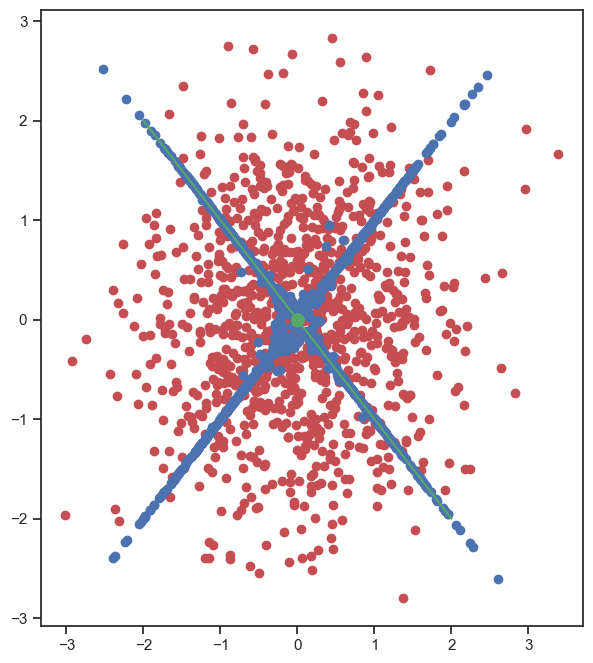

 10%|█         | 100/1000 [00:36<05:30,  2.72it/s]

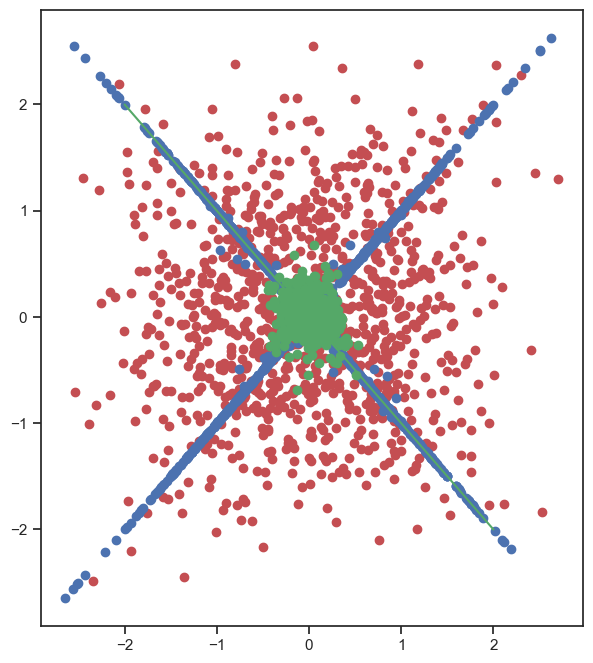

 20%|██        | 200/1000 [01:12<04:47,  2.78it/s]

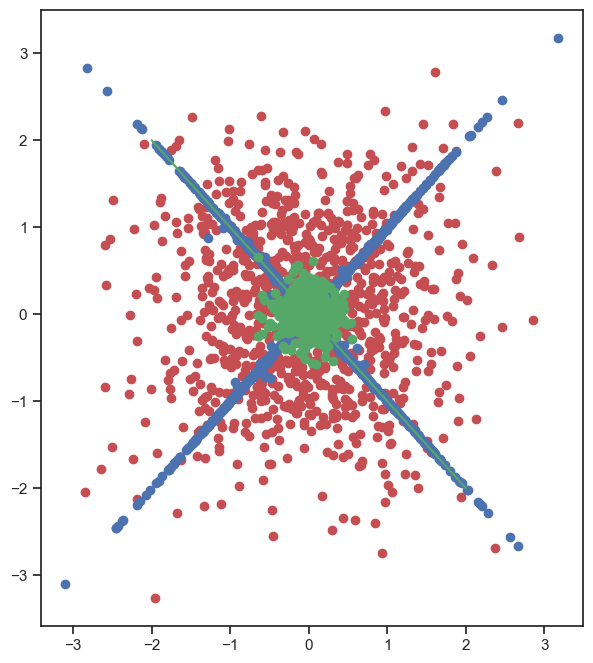

 30%|███       | 300/1000 [01:47<04:04,  2.87it/s]

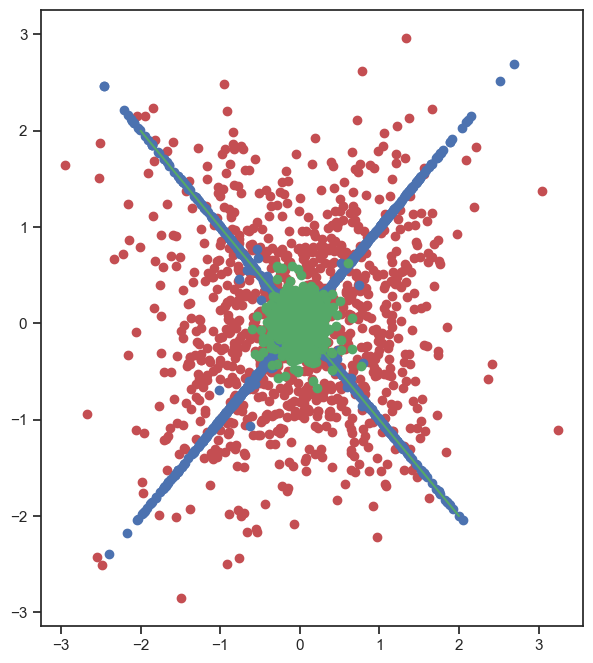

 40%|████      | 400/1000 [02:23<05:11,  1.93it/s]

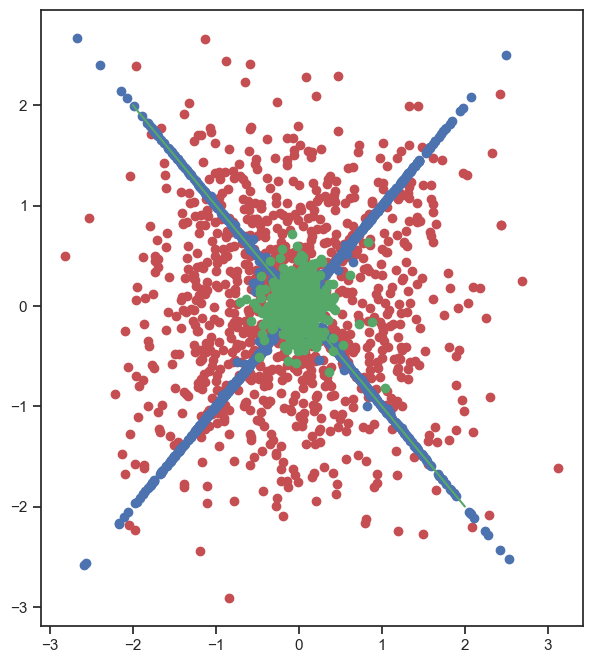

 50%|█████     | 500/1000 [02:59<02:52,  2.90it/s]

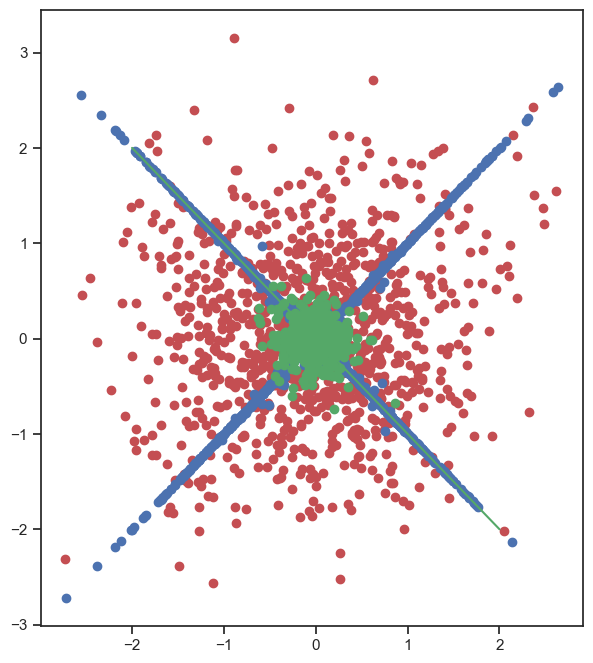

 60%|██████    | 600/1000 [03:37<02:18,  2.89it/s]

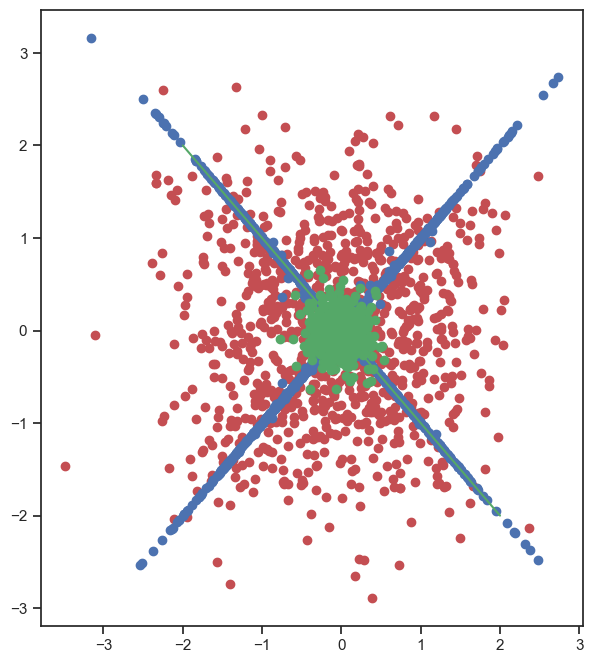

 70%|███████   | 700/1000 [04:13<01:45,  2.84it/s]

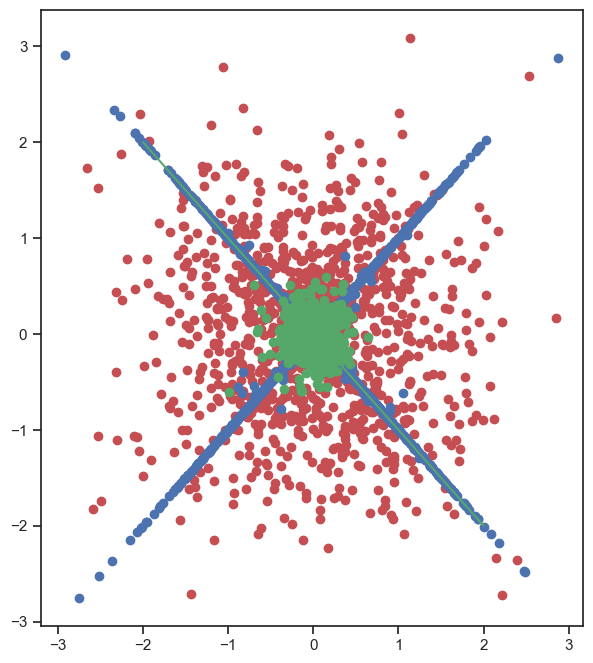

 80%|████████  | 800/1000 [04:48<01:10,  2.84it/s]

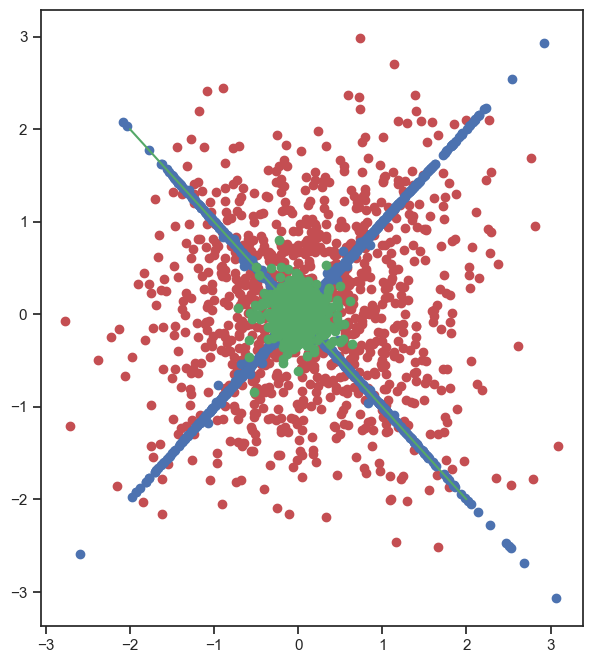

 90%|█████████ | 900/1000 [05:24<00:34,  2.88it/s]

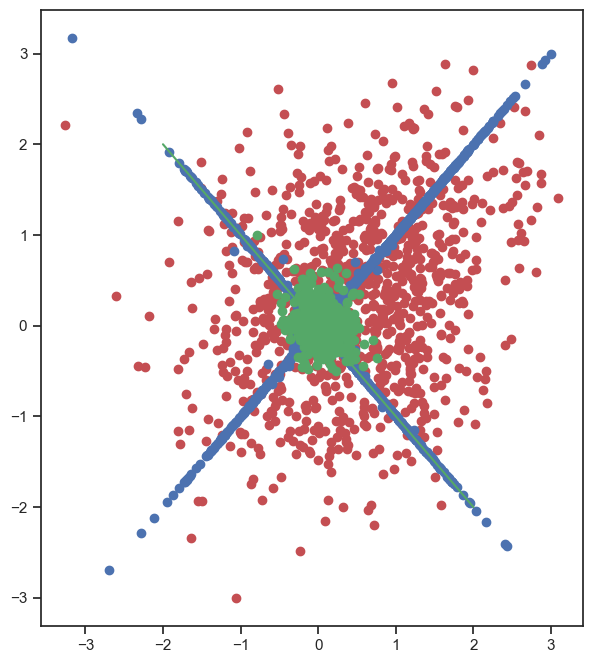

100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]


In [96]:
n_infer = 1000
from tqdm import tqdm

betas = 0.02 * torch.ones(T)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

with torch.no_grad():
    x = torch.randn(n_infer, input_dim)
    z = torch.randn_like(x)#optim_primal_dual(x, x, eps=0.0001, plot=False)
    mu = torch.zeros_like(x)

    record_steps = {999, 500, 200, 100, 50, 1}
    snapshots = {}
    snapshots_z = {}
    snapshots_mu = {}

    rho = 0.1
    eta = 0.01

    for t in tqdm(range(T, 0, -1)):

        t_tensor = (torch.ones(n_infer) * t / T).float()
        eps_theta = model(x, t_tensor)

        beta_t = betas[t - 1]
        alpha_t = alphas[t - 1]
        alpha_bar_t = alpha_bar[t - 1]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        x = (1 / torch.sqrt(alpha_t)) * (x - coef * eps_theta)

        if t > 1:
            #x update
            sigma_t = torch.sqrt(beta_t)
            x = x + sigma_t * torch.randn_like(x) - sigma_t * (rho * (x - z + mu))

            #z update
            w_prime = torch.randn_like(x)
            z = optim_primal_dual(z, x + mu + torch.sqrt(2* sigma_t) * w_prime, eps=0.0001, plot=False)

            #mu update
            mu = mu + eta * (x - z)

            plot=True

            if plot and t%100==0:

                fig, axes = plt.subplots(1, 1, figsize=(7, 8))
                axes.scatter(x[:,0], x[:,1], c='r')
                axes.scatter(z[:,0], z[:,1], c='b')
                axes.scatter(mu[:,0], mu[:,1], c='g')

                axes.plot([-2,-1,0,1,2], [2,1,0,-1,-2],c='g')
                #axes.plot([2,1,0,-1,-2], [2,1,0,-1,-2],c='g')
                plt.show()

        

        if t in record_steps:
            snapshots[t] = x.clone().cpu().numpy()
            snapshots_z[t] = z.clone().cpu().numpy()
            snapshots_mu[t] = mu.clone().cpu().numpy()

In [89]:
def eval_constraint(data, eps=0.01):
    
    constraint = data[:, 0] + data[:, 1]
    count = np.zeros_like(constraint)
    mask = (constraint >= - eps) & (constraint <= eps)  
    count[mask]=1

    return np.sum(count)/constraint.shape

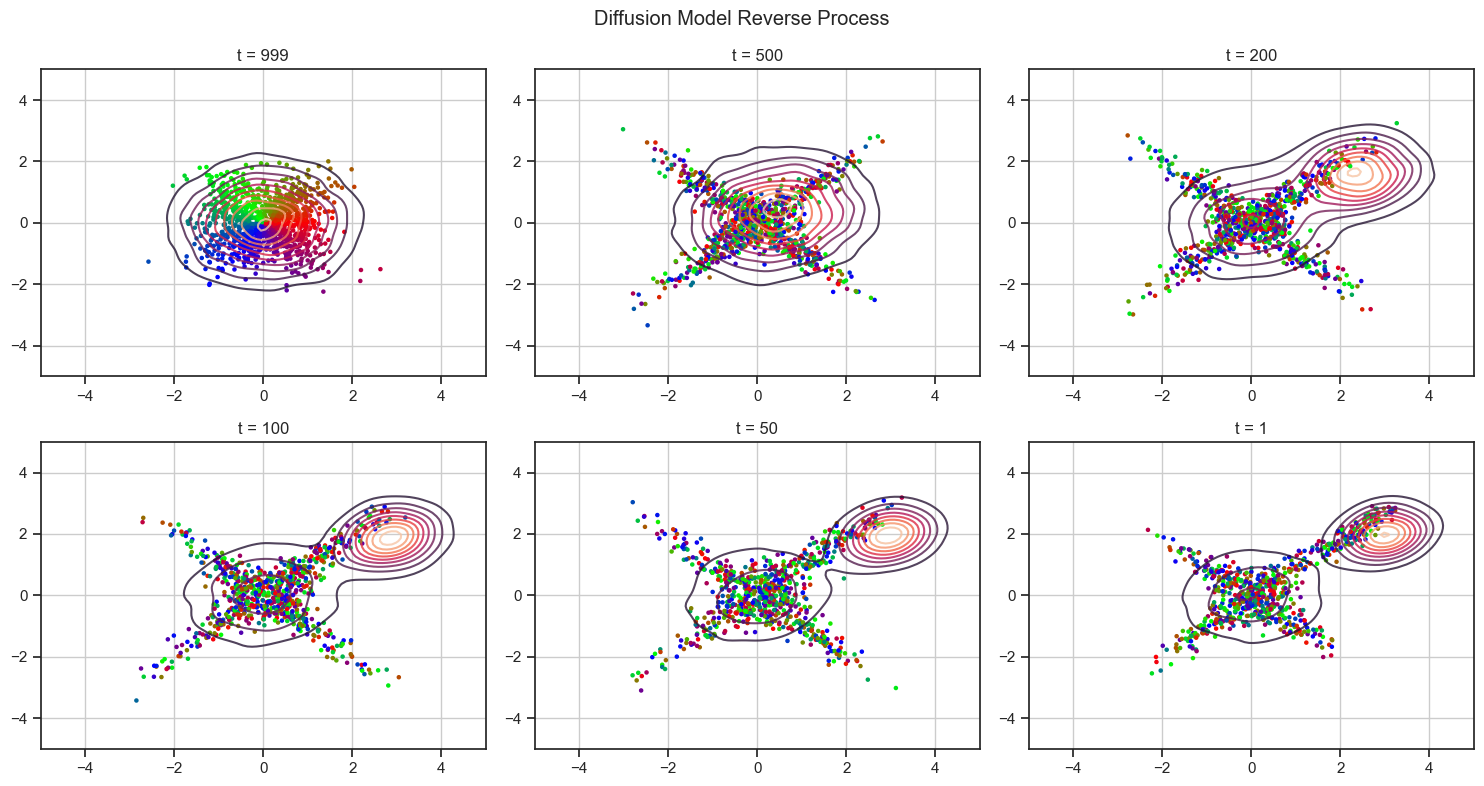

success score is [0.013] for epsilon 0.01


In [90]:
visualize_snapshots(snapshots) 
eps =0.01
score = eval_constraint(snapshots[1], eps=eps)
print(f'success score is {score} for epsilon {eps}')

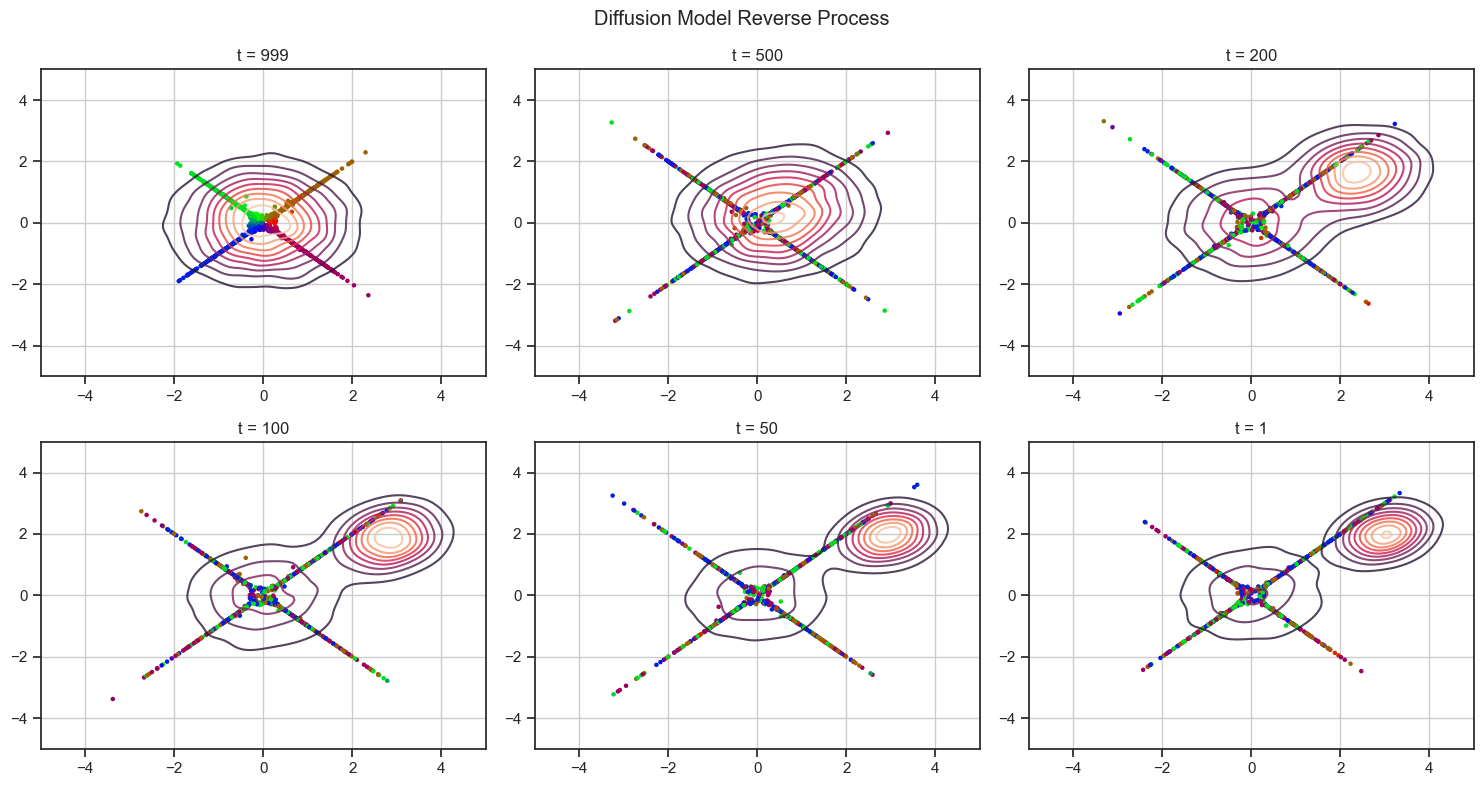

In [91]:
visualize_snapshots(snapshots_z) 

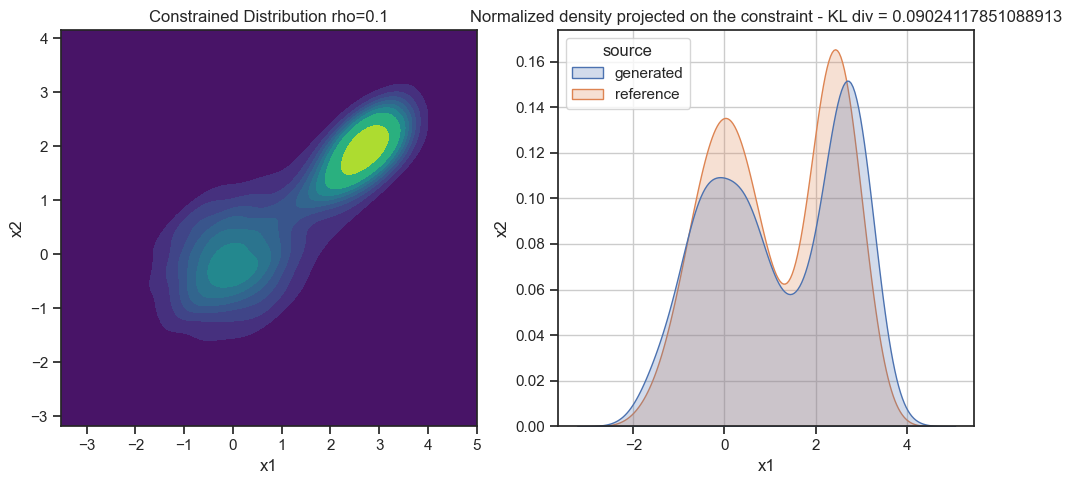

In [97]:
import pandas as pd
import seaborn as sns
from scipy.stats import entropy


def visualize_final_distribution(snapshot):

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))


    xx, yy = np.mgrid[-5:5:100j, -5:5:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    samples = snapshot

    x_0 = torch.FloatTensor(mixture.sample(num_samples))
    x_t, _ = ddpm.forward_process(x_0, t)
    samples_ = x_t.numpy()

    from scipy.stats import gaussian_kde
    kernel = gaussian_kde(samples_.T)
    density = np.reshape(kernel(positions).T, xx.shape)

    #axes[0].contourf(xx, yy, density, levels=10, alpha=0.8, cmap='hot')

    data = pd.DataFrame(snapshot, columns=["x1", "x2"])
    data['source'] = 'generated'


    sns.kdeplot(data=data,x="x1",y="x2",fill=True,cmap="viridis",clip=[[-5, 5], [-5, 5]],
    levels=10,ax=axes[0], thresh=0)


    #axes[0].scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=5)
    #ax.plot([-3,-2,-1,0,1,2,3], [3,2,1,0,-1,-2,-3],c='g')
    #axes[0].plot([3,2,1,0,-1,-2,-3], [3,2,1,0,-1,-2,-3],c='g')
    axes[0].set_title(f"t = {t}")
    axes[0].set_xlabel("x1")
    axes[0].set_ylabel("x2")
    axes[0].grid(True)

    axes[0].set_title("Constrained Distribution rho=0.1")


    coord_constraint = []
    density_constraint = []
    for i in range(xx.shape[0]):
        coord_constraint.append(xx[i, i])
        density_constraint.append(density[i,i])#[xx.shape[0]-1-i,i])

    density_constraint = density_constraint / np.sum(density_constraint)
    hist_constraint = np.trunc(1000 * density_constraint).astype(int)

    for i in range(len(hist_constraint)):
        n = hist_constraint[i]
        if n>0:
            row_data = {"x2": coord_constraint[i], "x1": coord_constraint[i], "source": "reference"}
            new_rows = pd.DataFrame([row_data] * n)  # Repeat the same row n times

            data = pd.concat([data, new_rows], ignore_index=True)


    generated = data[data['source'] == 'generated']
    reference = data[data['source'] == 'reference']

    generated_proj = (generated['x1'] + generated['x2']) / 2
    reference_proj = (reference['x1'] + reference['x2']) / 2

    bins = np.linspace(-5, 5, 50)
    p_hist, _ = np.histogram(generated_proj, bins=bins, density=True)
    q_hist, _ = np.histogram(reference_proj, bins=bins, density=True)

    eps = 1e-10
    p_hist = np.clip(p_hist, eps, None)
    q_hist = np.clip(q_hist, eps, None)

    kl_div = entropy(p_hist, q_hist)

    #fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    axes[1].set_title(f"Normalized density projected on the constraint - KL div = {kl_div}")
    axes[1].set_xlabel("x1")
    axes[1].set_ylabel("x2")
    axes[1].grid(True)

    sns.kdeplot(data, x="x1", hue='source', fill=True, ax=axes[1])
    #plt.suptitle("Distribution projected on the constraint space")
    plt.tight_layout()
    plt.show()



visualize_final_distribution(snapshots[1])
